# Visual Product Search Engine — YOLO Crop Generation + CLIP Fine-Tuning

**Pipeline:**
```
Original Image → YOLO Clothing Crop → Save Crop → (Image, Caption) Pair → CLIP Fine-Tuning → Save Checkpoint
```

**Notebook Scope:**
- Part 1: Load fine-tuned YOLO model
- Part 2: Generate clothing crops
- Part 3: Fallback handling (center crop)
- Part 4: Update metadata CSV
- Part 5–14: CLIP dataset preparation, model setup, partial fine-tuning, training pipeline, validation & visualization

**NOT covered here:** BLIP-2 captioning, retrieval/ANN indexing, Streamlit frontend, Recall@K/mAP evaluation.

## Environment Setup

In [1]:
# Install required libraries (Kaggle-friendly)
!pip install -q ultralytics transformers accelerate
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu118

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 7.5 MB/s eta 0:00:00


In [2]:
# ── Standard library
import os
import gc
import csv
import ast
import math
import time
import copy
import random
import logging
import warnings
from pathlib import Path
from copy import deepcopy
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple

# ── Scientific / data
import numpy as np
import pandas as pd
from PIL import Image

# ── PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.cuda.amp import GradScaler, autocast

# ── HuggingFace
from transformers import CLIPModel, CLIPProcessor

# ── Ultralytics YOLO
from ultralytics import YOLO

# ── Visualisation
import matplotlib
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')
logger = logging.getLogger(__name__)

# ── Three seeds (use your team roll-numbers here, per project spec)
# The spec says: "Results reported as mean ± std over 3–4 random seeds,
#                 using team members' roll numbers as seed values."
SEEDS = [1,52,525]   # ← replace with your actual roll numbers

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Seeds to run : {SEEDS}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using device: cuda
  GPU: Tesla T4
  VRAM: 15.6 GB
Seeds to run : [1, 52, 525]


## Configuration

In [3]:
@dataclass
class Config:
    # ── Paths
    yolo_model_path: str       = '/kaggle/input/models/saisathviksvn/yolo/other/default/1/yolov8n (1).pt'
    metadata_csv: str          = '/kaggle/input/datasets/saisathviksvn/metadata/metadata_parthiv.csv'
    crops_dir: str             = '/kaggle/working/processed/crops'
    output_dir: str            = '/kaggle/working'
    updated_metadata: str      = '/kaggle/working/updated_metadata.csv'
    clip_checkpoint_dir: str   = '/kaggle/working/checkpoints'

    # ── YOLO cropping
    yolo_conf_threshold: float = 0.25   # minimum confidence to accept detection
    crop_padding: int          = 10     # pixels to pad around detected bbox
    yolo_imgsz: int            = 640

    # ── CLIP model
    clip_model_name: str       = 'openai/clip-vit-base-patch32'
    max_text_length: int       = 77     # CLIP token limit

    # ── Training
    batch_size: int            = 32
    num_epochs: int            = 10
    learning_rate: float       = 1e-5
    weight_decay: float        = 1e-2
    warmup_steps: int          = 100
    val_split: float           = 0.10   # 10 % validation
    grad_clip: float           = 1.0
    grad_accum_steps: int      = 2      # effective batch = batch_size * grad_accum_steps
    num_workers: int           = 2
    pin_memory: bool           = True
    mixed_precision: bool      = True   # AMP

    # ── Fine-tuning strategy
    # Freeze the text encoder entirely; fine-tune only the last N vision transformer blocks
    freeze_text_encoder: bool  = True
    vision_blocks_to_train: int = 4    # last N blocks of vision transformer


CFG = Config()

# Make sure output directories exist
for d in [CFG.crops_dir, CFG.output_dir, CFG.clip_checkpoint_dir]:
    Path(d).mkdir(parents=True, exist_ok=True)

print('Config ready.')

Config ready.


---
## Part 1 — Load YOLO Model

In [4]:
def load_yolo(model_path: str, device: torch.device) -> YOLO:
    """Load Ultralytics YOLO model and move it to the correct device."""
    assert Path(model_path).exists(), f'YOLO model not found at: {model_path}'
    model = YOLO(model_path)
    # Ultralytics handles device placement internally; we pass device string
    logger.info(f'YOLO model loaded from {model_path}')
    return model


yolo_model = load_yolo(CFG.yolo_model_path, DEVICE)

# ── Sanity-check: run inference on a synthetic blank image
dummy_img = np.zeros((256, 256, 3), dtype=np.uint8)
dummy_result = yolo_model.predict(dummy_img, verbose=False, conf=CFG.yolo_conf_threshold)
print('YOLO sanity check passed — model responds to input.')
print(f'  Number of detections on blank image: {len(dummy_result[0].boxes)}')

2026-05-14 05:49:12,256 INFO YOLO model loaded from /kaggle/input/models/saisathviksvn/yolo/other/default/1/yolov8n (1).pt


YOLO sanity check passed — model responds to input.
  Number of detections on blank image: 0


---
## Part 2 — Generate Clothing Crops

In [5]:
def crop_with_padding(
    img: Image.Image,
    bbox: Tuple[int, int, int, int],
    padding: int = 10
) -> Image.Image:
    """
    Crop a PIL image using (x1, y1, x2, y2) bounding box with padding.
    Coordinates are clamped so they never exceed image bounds.
    """
    w, h = img.size
    x1, y1, x2, y2 = bbox
    x1 = max(0, x1 - padding)
    y1 = max(0, y1 - padding)
    x2 = min(w, x2 + padding)
    y2 = min(h, y2 + padding)
    return img.crop((x1, y1, x2, y2))


def center_crop_fallback(img: Image.Image) -> Image.Image:
    """
    Fallback: crop the central 80% of the image when YOLO fails to detect anything.
    """
    w, h = img.size
    margin_x = int(w * 0.10)
    margin_y = int(h * 0.10)
    return img.crop((margin_x, margin_y, w - margin_x, h - margin_y))


def get_best_detection(
    result,
    conf_threshold: float
) -> Optional[Tuple[Tuple[int, int, int, int], float]]:
    """
    Given a YOLO result for a single image, return the highest-confidence
    bounding box (x1, y1, x2, y2) and confidence, or None if no detection
    meets the threshold.
    """
    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        return None

    confs = boxes.conf.cpu().numpy()
    mask = confs >= conf_threshold
    if not mask.any():
        return None

    best_idx = int(np.argmax(confs))
    xyxy = boxes.xyxy[best_idx].cpu().numpy().astype(int)
    x1, y1, x2, y2 = xyxy
    return (x1, y1, x2, y2), float(confs[best_idx])


print('Cropping utility functions defined.')

Cropping utility functions defined.


---
## Part 3 — Full Cropping Pipeline (with Fallback Handling)

In [6]:
def run_crop_pipeline(
    df: pd.DataFrame,
    yolo: YOLO,
    cfg: Config
) -> pd.DataFrame:
    """
    Iterate over rows of the metadata DataFrame, run YOLO inference on each
    original image, crop the primary clothing region, and save the crop.

    Detection status values written to the output DataFrame:
      'success'        — YOLO detected a clothing item
      'fallback_crop'  — YOLO failed; center-crop fallback used
      'failed'         — Image could not be opened at all

    Returns an updated copy of df with columns:
      crop_path, bbox, confidence, detection_status
    """
    records = []
    counters = {'success': 0, 'fallback_crop': 0, 'failed': 0}
    crops_root = Path(cfg.crops_dir)

    for _, row in tqdm(df.iterrows(), total=len(df), desc='Generating crops'):
        img_path = Path(str(row['image_path']))
        item_id  = str(row['item_id'])

        # ── Derive save path: preserve filename, group by item_id
        save_dir  = crops_root / item_id
        save_dir.mkdir(parents=True, exist_ok=True)
        save_path = save_dir / img_path.name

        record = row.to_dict()

        # ── Try to open the image
        try:
            img = Image.open(img_path).convert('RGB')
        except Exception as e:
            logger.warning(f'Cannot open image {img_path}: {e}')
            record.update({
                'crop_path': str(save_path),
                'bbox': None,
                'confidence': 0.0,
                'detection_status': 'failed'
            })
            counters['failed'] += 1
            records.append(record)
            continue

        # ── Run YOLO inference
        try:
            results = yolo.predict(
                source=str(img_path),
                imgsz=cfg.yolo_imgsz,
                conf=cfg.yolo_conf_threshold,
                verbose=False
            )
            detection = get_best_detection(results[0], cfg.yolo_conf_threshold)
        except Exception as e:
            logger.warning(f'YOLO inference failed for {img_path}: {e}')
            detection = None

        if detection is not None:
            # ── Successful YOLO detection
            bbox, conf = detection
            crop = crop_with_padding(img, bbox, cfg.crop_padding)
            status = 'success'
            counters['success'] += 1
        else:
            # ── Fallback to center crop
            crop  = center_crop_fallback(img)
            bbox  = None
            conf  = 0.0
            status = 'fallback_crop'
            counters['fallback_crop'] += 1
            logger.debug(f'Fallback crop used for {img_path}')

        # ── Save crop
        crop.save(save_path)

        record.update({
            'crop_path': str(save_path),
            'bbox': str(bbox),
            'confidence': round(conf, 4),
            'detection_status': status
        })
        records.append(record)

    out_df = pd.DataFrame(records)

    # ── Summary
    total = len(out_df)
    print('\n── Crop pipeline summary ──')
    print(f'  Total images   : {total}')
    print(f'  YOLO success   : {counters["success"]}  ({counters["success"]/total*100:.1f}%)')
    print(f'  Fallback crops : {counters["fallback_crop"]}  ({counters["fallback_crop"]/total*100:.1f}%)')
    print(f'  Failed         : {counters["failed"]}  ({counters["failed"]/total*100:.1f}%)')

    return out_df


# ── Load metadata
meta_df = pd.read_csv(CFG.metadata_csv)
OLD_ROOT = "/kaggle/input/datasets/abhinavkishan123/deepfashion-inshop-dataset/Dataset"
NEW_ROOT = "/kaggle/input/datasets/svnsaisathvik/text-images"

meta_df["image_path"] = meta_df["image_path"].str.replace(
    OLD_ROOT,
    NEW_ROOT,
    regex=False
)
print(f'Metadata loaded: {len(meta_df):,} rows')
print(meta_df.dtypes)
meta_df.head(3)

Metadata loaded: 52,712 rows
image_path           object
item_id              object
gender               object
category             object
crop_path            object
caption              object
bbox                 object
confidence          float64
detection_status     object
dtype: object


,image_path,item_id,gender,category,crop_path,caption,bbox,confidence,detection_status
0,/kaggle/input/datasets/svnsaisathvik/text-imag...,id_00000080,MEN,Denim,/kaggle/working/processed/crops/id_00000080/01...,The black skinny jeans,"[66,0,207,256]",0.8184,success
1,/kaggle/input/datasets/svnsaisathvik/text-imag...,id_00000080,MEN,Denim,/kaggle/working/processed/crops/id_00000080/01...,black skinny jeans,"[99,0,175,256]",0.7378,success
2,/kaggle/input/datasets/svnsaisathvik/text-imag...,id_00000080,MEN,Denim,/kaggle/working/processed/crops/id_00000080/01...,Jeans,"[62,0,190,256]",0.7669,success


In [7]:
# ── NOTE: If the metadata already contains valid crop_path entries (pre-generated crops),
#    you can skip re-running YOLO and jump directly to Part 5.
#    The cell below checks whether crops already exist.

def crops_already_exist(df: pd.DataFrame, crops_col: str = 'crop_path') -> bool:
    """Return True only if ALL crop paths in the DataFrame exist on disk."""
    if crops_col not in df.columns:
        return False
    paths = df[crops_col].dropna().tolist()
    if not paths:
        return False
    missing = [p for p in paths if not Path(p).exists()]
    if missing:
        print(f'{len(missing)} crop files are missing (sample: {missing[:3]})')
        return False
    return True


SKIP_CROP_GENERATION = crops_already_exist(meta_df)
print(f'Skip crop generation? {SKIP_CROP_GENERATION}')

52712 crop files are missing (sample: ['/kaggle/working/processed/crops/id_00000080/01_1_front.jpg', '/kaggle/working/processed/crops/id_00000080/01_2_side.jpg', '/kaggle/working/processed/crops/id_00000080/01_3_back.jpg'])
Skip crop generation? False


In [8]:
if SKIP_CROP_GENERATION:
    print('Crops already present — skipping YOLO crop pipeline.')
    updated_df = meta_df.copy()
else:
    updated_df = run_crop_pipeline(meta_df, yolo_model, CFG)

print(f'Updated DataFrame shape: {updated_df.shape}')

Generating crops:   0%|          | 0/52712 [00:00<?, ?it/s]


── Crop pipeline summary ──
  Total images   : 52712
  YOLO success   : 51343  (97.4%)
  Fallback crops : 1369  (2.6%)
  Failed         : 0  (0.0%)
Updated DataFrame shape: (52712, 9)


---
## Part 4 — Update Metadata CSV

In [9]:
# Ensure required columns are present
required_cols = ['image_path', 'crop_path', 'item_id', 'caption',
                 'category', 'gender', 'bbox', 'confidence', 'detection_status']

for col in required_cols:
    if col not in updated_df.columns:
        updated_df[col] = None

updated_df = updated_df[required_cols + [c for c in updated_df.columns if c not in required_cols]]

# Drop rows where both crop_path is missing AND detection failed
before = len(updated_df)
updated_df = updated_df[updated_df['detection_status'] != 'failed'].reset_index(drop=True)
print(f'Rows dropped (failed detections): {before - len(updated_df)}')

# Save
updated_df.to_csv(CFG.updated_metadata, index=False)
print(f'Saved updated metadata → {CFG.updated_metadata}')
print(f'  Total usable rows: {len(updated_df):,}')

updated_df.head(3)

Rows dropped (failed detections): 0
Saved updated metadata → /kaggle/working/updated_metadata.csv
  Total usable rows: 52,712


,image_path,crop_path,item_id,caption,category,gender,bbox,confidence,detection_status
0,/kaggle/input/datasets/svnsaisathvik/text-imag...,/kaggle/working/processed/crops/id_00000080/01...,id_00000080,The black skinny jeans,Denim,MEN,"(np.int64(72), np.int64(0), np.int64(200), np....",0.8184,success
1,/kaggle/input/datasets/svnsaisathvik/text-imag...,/kaggle/working/processed/crops/id_00000080/01...,id_00000080,black skinny jeans,Denim,MEN,"(np.int64(102), np.int64(0), np.int64(171), np...",0.7378,success
2,/kaggle/input/datasets/svnsaisathvik/text-imag...,/kaggle/working/processed/crops/id_00000080/01...,id_00000080,Jeans,Denim,MEN,"(np.int64(67), np.int64(0), np.int64(184), np....",0.7669,success


---
## Part 5 — CLIP Dataset Preparation

In [10]:
class ClothingDataset(Dataset):
    """
    PyTorch Dataset for CLIP fine-tuning.

    Each sample returns a (cropped_image, caption) pair, pre-processed
    by the HuggingFace CLIPProcessor so images are tensors and captions
    are tokenised.

    CHANGE: __getitem__ now also returns 'item_id' (str) so that the
    ItemIDAwareBatchSampler can verify grouping during debug logging,
    and so future losses (e.g. SupCon) can use the label directly.

    Args:
        df          : DataFrame with at minimum 'crop_path', 'caption',
                      and 'item_id' columns.
        processor   : Loaded CLIPProcessor instance.
        max_length  : Maximum token length for captions (CLIP hard limit = 77).
    """

    def __init__(self, df: pd.DataFrame, processor: CLIPProcessor, max_length: int = 77):
        # Keep only rows with a valid crop_path, caption, and item_id
        self.df = df.dropna(subset=['crop_path', 'caption', 'item_id']).reset_index(drop=True)
        # Further filter to rows whose crop file actually exists
        mask = self.df['crop_path'].apply(lambda p: Path(p).exists())
        n_missing = (~mask).sum()
        if n_missing > 0:
            print(f'  [Dataset] Dropping {n_missing} rows — crop file not found on disk.')
        self.df = self.df[mask].reset_index(drop=True)
        self.processor  = processor
        self.max_length = max_length

        # ── Pre-build item_id → list-of-indices mapping (O(N) one-time cost).
        # This avoids any full-dataset scan at batch-construction time and is
        # the key structure used by ItemIDAwareBatchSampler.
        self.item_id_to_indices: Dict[str, List[int]] = {}
        for idx, item_id in enumerate(self.df['item_id'].astype(str)):
            self.item_id_to_indices.setdefault(item_id, []).append(idx)

        print(f'  [Dataset] {len(self.df):,} samples | {len(self.item_id_to_indices):,} unique item_ids')

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        row     = self.df.iloc[idx]
        caption = str(row['caption'])
        item_id = str(row['item_id'])

        # ── Load crop image
        try:
            img = Image.open(row['crop_path']).convert('RGB')
        except Exception:
            # Return a blank image if the file is unreadable
            img = Image.new('RGB', (224, 224), color=(128, 128, 128))

        # ── CLIP Processor encodes image + text together
        inputs = self.processor(
            text=[caption],
            images=img,
            return_tensors='pt',
            padding='max_length',
            max_length=self.max_length,
            truncation=True
        )

        # Remove the batch dimension added by the processor
        return {
            'pixel_values'  : inputs['pixel_values'].squeeze(0),        # (3, H, W)
            'input_ids'     : inputs['input_ids'].squeeze(0),           # (seq_len,)
            'attention_mask': inputs['attention_mask'].squeeze(0),      # (seq_len,)
            'item_id'       : item_id,                                   # str — group label
        }


print('ClothingDataset class defined.')

ClothingDataset class defined.


---
## Part 6 — CLIP Model Setup

In [11]:
print(f'Loading CLIP model: {CFG.clip_model_name}')
clip_processor = CLIPProcessor.from_pretrained(CFG.clip_model_name)
clip_model     = CLIPModel.from_pretrained(CFG.clip_model_name)
clip_model.to(DEVICE)
print('CLIP model and processor loaded.')

total_params = sum(p.numel() for p in clip_model.parameters())
print(f'  Total parameters : {total_params/1e6:.1f} M')

Loading CLIP model: openai/clip-vit-base-patch32


2026-05-14 06:02:46,237 INFO HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-05-14 06:02:46,436 INFO HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-05-14 06:02:46,641 INFO HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/chat_template.json "HTTP/1.1 404 Not Found"
2026-05-14 06:02:46,642 WARNING Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-05-14 06:02:46,838 INFO HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
2026-05-14 06:02:47,041 INFO HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/audio_tokenizer_config.json "HTTP/1.1 404 

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
2026-05-14 06:02:47,666 INFO HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-05-14 06:02:47,862 INFO HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
2026-05-14 06:02:47,869 INFO HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/openai/clip-vit-base-patch32/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268/preprocessor_config.json "HTTP/1.1 200 OK"
2026-05-14 06:02:48,087 INFO HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json "HTTP/1.1 307 Temporar

config.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

2026-05-14 06:02:59,015 INFO HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-05-14 06:02:59,217 INFO HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32 "HTTP/1.1 200 OK"
2026-05-14 06:02:59,433 INFO HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/commits/main "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

2026-05-14 06:02:59,700 INFO HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/discussions?p=0 "HTTP/1.1 200 OK"
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-05-14 06:02:59,999 INFO HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/commits/refs%2Fpr%2F66 "HTTP/1.1 200 OK"


CLIP model and processor loaded.
  Total parameters : 151.3 M


## Dataset preperation

In [12]:
# ── Construct the full dataset
full_dataset = ClothingDataset(updated_df, clip_processor, CFG.max_text_length)

# ── Train / validation split (90 / 10)
n_total = len(full_dataset)
n_val   = max(1, int(n_total * CFG.val_split))
n_train = n_total - n_val

train_dataset, val_dataset = random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(SEEDS[0])
)

print(f'Total samples : {n_total:,}')
print(f'Train samples : {n_train:,}')
print(f'Val samples   : {n_val:,}')

2026-05-14 06:03:00,396 INFO HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/refs%2Fpr%2F66/model.safetensors "HTTP/1.1 302 Found"
2026-05-14 06:03:00,595 INFO HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/xet-read-token/c237dc49a33fc61debc9276459120b7eac67e7ef "HTTP/1.1 200 OK"


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

  [Dataset] 52,258 samples | 7,980 unique item_ids
Total samples : 52,258
Train samples : 47,033
Val samples   : 5,225


---
## Part 7 — Partial Fine-Tuning Strategy

Following the project spec:
- **Freeze** the entire text encoder.
- **Freeze** vision transformer blocks 0 … (N-K-1).
- **Train** only the last K vision transformer blocks (default K=4) and the visual/text projection layers.

In [13]:
def configure_trainable_params(model: CLIPModel, cfg: Config) -> None:
    """
    Apply the partial fine-tuning strategy:

    FROZEN:
      - Full text encoder (embeddings + transformer blocks + layer norm)
      - Vision encoder patch embedding and positional embedding
      - Vision transformer blocks 0 .. (total_blocks - vision_blocks_to_train - 1)

    TRAINABLE:
      - Last `vision_blocks_to_train` vision transformer blocks
      - Vision post layer norm
      - Visual projection layer
      - Text projection layer (scalar bridging loss benefit)
    """
    # ── 1. Freeze everything first
    for param in model.parameters():
        param.requires_grad = False

    # ── 2. Unfreeze last N vision transformer blocks
    vision_blocks = model.vision_model.encoder.layers
    total_blocks  = len(vision_blocks)
    n_train       = min(cfg.vision_blocks_to_train, total_blocks)
    train_from    = total_blocks - n_train

    for i, block in enumerate(vision_blocks):
        if i >= train_from:
            for param in block.parameters():
                param.requires_grad = True   # TRAINABLE

    # ── 3. Unfreeze vision post layer norm
    for param in model.vision_model.post_layernorm.parameters():
        param.requires_grad = True           # TRAINABLE

    # ── 4. Unfreeze projection layers
    model.visual_projection.weight.requires_grad = True  # TRAINABLE
    model.text_projection.weight.requires_grad   = True  # TRAINABLE

    # ── 5. Report
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    print(f'Partial fine-tuning configured:')
    print(f'  Vision blocks : training blocks {train_from}–{total_blocks-1} (last {n_train} of {total_blocks})')
    print(f'  Text encoder  : fully FROZEN')
    print(f'  Trainable params : {trainable/1e6:.2f} M')
    print(f'  Frozen params    : {frozen/1e6:.2f} M')


configure_trainable_params(clip_model, CFG)

Partial fine-tuning configured:
  Vision blocks : training blocks 8–11 (last 4 of 12)
  Text encoder  : fully FROZEN
  Trainable params : 29.01 M
  Frozen params    : 122.27 M


---
## Part 8 — Build DataLoaders

---
## Why item_id-aware Batching Improves Visual Retrieval Training

### The Problem with Random Batching
Standard random shuffling treats all samples as independent.  With DeepFashion's
~7,000+ item IDs and many images per item, a random batch of 32 is almost certain
to contain **at most one** image per item.  That leaves CLIP's contrastive loss
with no *within-batch positives* — it can only push negatives apart, not pull
same-item embeddings together.

### How Grouped Batching Fixes This
By constructing each batch to contain **multiple images of the same item_id**, we
guarantee that same-item pairs are in the denominator of the InfoNCE sum together.
Concretely:

| Property | Random batching | item_id-aware batching |
|---|---|---|
| Same-item pairs per batch | ~0 | ≥ `positives_per_item × n_items_per_batch` |
| Contrastive signal | Only push negatives apart | Pull positives + push negatives |
| Embedding space | Items scattered | Items clustered by product |
| Recall@K at retrieval | Lower | Higher |

### Implementation Strategy: `ItemIDAwareBatchSampler`
1. **Group-by construction** — build `item_id → [indices]` once at dataset init (O(N)).
2. **Per-epoch shuffle** — shuffle both the group order and each group's indices so
   every epoch sees different positive combinations.
3. **Fill remainder with negatives** — if a batch slot is not filled by positives
   (e.g. item has only 1 image), negatives from other items are drawn to reach
   `batch_size`, preserving the standard contrastive loss denominator size.
4. **Zero memory overhead** — only integer index lists are stored, no image tensors.

### Why This Still Works With the Current Loss
The `clip_contrastive_loss` function uses the **diagonal** as the positive target
(each image matches its own caption).  With grouped batches the off-diagonal
entries now contain *some* same-item pairs, which act as **semi-hard negatives** —
harder than random negatives and therefore more informative gradients.


In [14]:
class ItemIDAwareBatchSampler(torch.utils.data.Sampler):
    """
    Custom batch sampler that groups samples sharing the same item_id
    into the same training batch.

    WHY THIS HELPS:
    ─────────────
    CLIP's InfoNCE contrastive loss treats the (i-th image, i-th caption)
    pair as the positive and all j≠i pairs as negatives within the batch.
    When multiple images of the SAME product appear in one batch, they act
    as *semi-hard same-class negatives* — they are harder to separate than
    random images, generating richer gradients and tighter product clusters
    in embedding space.  This directly improves Recall@K at retrieval time.

    HOW BATCHES ARE BUILT:
    ─────────────────────
    1. Shuffle item groups (so each epoch has a different item order).
    2. Emit ALL samples from each group contiguously.
    3. Collect into a running buffer; once buffer reaches batch_size, yield.
    4. drop_last=True drops the final incomplete batch.

    MEMORY EFFICIENCY:
    ─────────────────
    Only integer index lists are stored — no tensors, no image copies.

    Args:
        dataset          : A ClothingDataset instance (must have
                           `item_id_to_indices` attribute).
        batch_size       : Number of samples per batch.
        drop_last        : If True, drop the final batch if smaller
                           than batch_size (recommended for InfoNCE).
        shuffle          : Shuffle group order and within-group order
                           every epoch.
    """

    def __init__(
        self,
        dataset: 'ClothingDataset',
        batch_size: int,
        positives_per_item: int = 2,   # kept for API compat, no longer used
        drop_last: bool = True,
        shuffle: bool = True,
    ):
        super().__init__()
        assert hasattr(dataset, 'item_id_to_indices'), (
            "Dataset must have `item_id_to_indices` dict. "
            "Use ClothingDataset or add the attribute manually."
        )
        self.dataset            = dataset
        self.batch_size         = batch_size
        self.drop_last          = drop_last
        self.shuffle            = shuffle

        self.groups: List[List[int]] = list(dataset.item_id_to_indices.values())
        self.all_indices: List[int]  = list(range(len(dataset)))

        n_groups  = len(self.groups)
        n_samples = len(dataset)
        print(f'  [ItemIDAwareBatchSampler] {n_groups:,} item groups | ')
        print(f'    {n_samples:,} total samples | batch_size={batch_size} | ')
        print(f'    drop_last={drop_last} | full dataset coverage mode')

    def __iter__(self):
        groups = [g.copy() for g in self.groups]

        if self.shuffle:
            random.shuffle(groups)
            for g in groups:
                random.shuffle(g)

        # Flatten ALL samples group by group — positives stay contiguous
        all_ordered = [idx for group in groups for idx in group]

        # Yield full batches
        for start in range(0, len(all_ordered) - self.batch_size + 1, self.batch_size):
            yield all_ordered[start:start + self.batch_size]

    def __len__(self) -> int:
        return len(self.all_indices) // self.batch_size


print('ItemIDAwareBatchSampler defined.')

ItemIDAwareBatchSampler defined.


In [15]:
class _SubsetItemIDAwareBatchSampler(torch.utils.data.Sampler):
    def __init__(self, subset, batch_size, drop_last=True, shuffle=True):
        super().__init__()
        global_to_local = {g: l for l, g in enumerate(subset.indices)}

        local_id_to_indices: Dict[str, List[int]] = {}
        base_df = subset.dataset.df

        for global_idx in subset.indices:
            item_id = str(base_df.iloc[global_idx]['item_id'])
            local_idx = global_to_local[global_idx]
            local_id_to_indices.setdefault(item_id, []).append(local_idx)

        class _FakeDataset:
            def __init__(self, id_to_indices, n):
                self.item_id_to_indices = id_to_indices
                self._n = n
            def __len__(self):
                return self._n

        fake = _FakeDataset(local_id_to_indices, len(subset))

        self._sampler = ItemIDAwareBatchSampler(
            dataset=fake,
            batch_size=batch_size,
            drop_last=drop_last,
            shuffle=shuffle,
        )
        self._sampler.all_indices = list(range(len(subset)))
        self._sampler.groups = list(local_id_to_indices.values())

    def __iter__(self):
        return iter(self._sampler)

    def __len__(self):
        return len(self._sampler)


# ── Instantiate the sampler
train_sampler = _SubsetItemIDAwareBatchSampler(
    subset=train_dataset,
    batch_size=CFG.batch_size,
    drop_last=True,
    shuffle=True,
)

# ── Training DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_sampler=train_sampler,
    num_workers=CFG.num_workers,
    pin_memory=CFG.pin_memory and DEVICE.type == 'cuda',
)

# ── Validation DataLoader
val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=CFG.pin_memory and DEVICE.type == 'cuda',
)

print(f'Train batches (approx): {len(train_loader)}')
print(f'Val batches           : {len(val_loader)}')

print('\n── [Debug] item_id distribution in first 3 batches ──')
_debug_iter = iter(train_loader)
for _b_idx in range(min(3, len(train_loader))):
    try:
        _batch = next(_debug_iter)
    except StopIteration:
        break
    _ids = _batch['item_id']
    from collections import Counter
    _counts = Counter(_ids)
    _repeated = {k: v for k, v in _counts.items() if v > 1}
    print(f'  Batch {_b_idx+1}: {len(_ids)} samples | ')
    print(f'    unique item_ids: {len(_counts)} | ')
    print(f'    item_ids with >1 sample: {len(_repeated)}')
    if _repeated:
        for _iid, _cnt in list(_repeated.items())[:3]:
            print(f'      item_id={_iid!r} appears {_cnt}× in this batch ✓')
del _debug_iter
print('── [Debug] done ──\n')

  [ItemIDAwareBatchSampler] 7,978 item groups | 
    47,033 total samples | batch_size=32 | 
    drop_last=True | full dataset coverage mode
Train batches (approx): 1469
Val batches           : 164

── [Debug] item_id distribution in first 3 batches ──
  Batch 1: 32 samples | 
    unique item_ids: 5 | 
    item_ids with >1 sample: 5
      item_id='id_00000412' appears 17× in this batch ✓
      item_id='id_00004544' appears 4× in this batch ✓
      item_id='id_00000634' appears 4× in this batch ✓
  Batch 2: 32 samples | 
    unique item_ids: 9 | 
    item_ids with >1 sample: 8
      item_id='id_00005322' appears 3× in this batch ✓
      item_id='id_00005785' appears 2× in this batch ✓
      item_id='id_00001073' appears 4× in this batch ✓
  Batch 3: 32 samples | 
    unique item_ids: 8 | 
    item_ids with >1 sample: 7
      item_id='id_00002016' appears 2× in this batch ✓
      item_id='id_00001716' appears 4× in this batch ✓
      item_id='id_00001045' appears 12× in this batch ✓
── [

---
## Part 9 — Contrastive Loss

In [16]:
def clip_contrastive_loss(image_embeds: torch.Tensor, text_embeds: torch.Tensor, logit_scale: torch.Tensor) -> torch.Tensor:
    """
    Standard CLIP symmetric cross-entropy contrastive loss.

    Computes:
      L = 0.5 * (CE(image→text) + CE(text→image))

    Both image_embeds and text_embeds should be L2-normalised and have shape (N, D).
    logit_scale is the learnable temperature parameter from CLIPModel.
    """
    # L2 normalise
    image_embeds = F.normalize(image_embeds, dim=-1)
    text_embeds  = F.normalize(text_embeds,  dim=-1)

    # Scale logits
    logit_scale = logit_scale.exp().clamp(max=100.0)  # prevent runaway scale
    logits_per_image = logit_scale * image_embeds @ text_embeds.T   # (N, N)
    logits_per_text  = logits_per_image.T                            # (N, N)

    # Ground truth: identity (each image matches its own caption)
    labels = torch.arange(len(image_embeds), device=image_embeds.device)

    loss_i2t = F.cross_entropy(logits_per_image, labels)
    loss_t2i = F.cross_entropy(logits_per_text,  labels)

    return (loss_i2t + loss_t2i) / 2.0


print('Contrastive loss function defined.')

Contrastive loss function defined.


---
## Part 10 — Optimizer and Scheduler

In [17]:
# Only pass parameters that require gradients to the optimizer
trainable_params = [p for p in clip_model.parameters() if p.requires_grad]
print(f'Parameter groups passed to optimizer: {len(trainable_params)}')

optimizer = torch.optim.AdamW(
    trainable_params,
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
    betas=(0.9, 0.98),
    eps=1e-6
)

total_steps   = (len(train_loader) // CFG.grad_accum_steps) * CFG.num_epochs
warmup_steps  = CFG.warmup_steps

def lr_lambda(current_step: int) -> float:
    """Linear warmup followed by cosine decay."""
    if current_step < warmup_steps:
        return float(current_step) / float(max(1, warmup_steps))
    progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
scaler    = GradScaler(enabled=CFG.mixed_precision and DEVICE.type == 'cuda')

print(f'Total training steps : {total_steps}')
print(f'Warmup steps         : {warmup_steps}')

Parameter groups passed to optimizer: 68
Total training steps : 7340
Warmup steps         : 100


---
## Part 11 — Training & Validation Loop

In [18]:
def train_one_epoch(
    model: CLIPModel,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scheduler,
    scaler: GradScaler,
    cfg: Config,
    epoch: int
) -> float:
    """Run one training epoch. Returns mean loss."""
    model.train()
    total_loss   = 0.0
    num_batches  = 0

    pbar = tqdm(loader, desc=f'[Train] Epoch {epoch+1}/{cfg.num_epochs}', leave=False)
    optimizer.zero_grad()

    for step, batch in enumerate(pbar):
        pixel_values   = batch['pixel_values'].to(DEVICE, non_blocking=True)
        input_ids      = batch['input_ids'].to(DEVICE, non_blocking=True)
        attention_mask = batch['attention_mask'].to(DEVICE, non_blocking=True)

        with autocast(enabled=cfg.mixed_precision and DEVICE.type == 'cuda'):
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            loss = clip_contrastive_loss(
                outputs.image_embeds,
                outputs.text_embeds,
                model.logit_scale
            )
            loss = loss / cfg.grad_accum_steps

        scaler.scale(loss).backward()

        if (step + 1) % cfg.grad_accum_steps == 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()

        total_loss  += loss.item() * cfg.grad_accum_steps
        num_batches += 1
        pbar.set_postfix({'loss': f'{total_loss/num_batches:.4f}'})

    return total_loss / max(1, num_batches)


@torch.no_grad()
def validate(
    model: CLIPModel,
    loader: DataLoader,
    cfg: Config,
    epoch: int
) -> float:
    """Run validation. Returns mean loss."""
    model.eval()
    total_loss   = 0.0
    num_batches  = 0

    pbar = tqdm(loader, desc=f'[Val]   Epoch {epoch+1}/{cfg.num_epochs}', leave=False)

    for batch in pbar:
        pixel_values   = batch['pixel_values'].to(DEVICE, non_blocking=True)
        input_ids      = batch['input_ids'].to(DEVICE, non_blocking=True)
        attention_mask = batch['attention_mask'].to(DEVICE, non_blocking=True)

        with autocast(enabled=cfg.mixed_precision and DEVICE.type == 'cuda'):
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            loss = clip_contrastive_loss(
                outputs.image_embeds,
                outputs.text_embeds,
                model.logit_scale
            )

        total_loss  += loss.item()
        num_batches += 1
        pbar.set_postfix({'val_loss': f'{total_loss/num_batches:.4f}'})

    return total_loss / max(1, num_batches)


print('Training and validation functions defined.')

Training and validation functions defined.


---
## Part 12 — Checkpointing Helper

In [19]:
def save_checkpoint(
    model: CLIPModel,
    optimizer,
    scheduler,
    epoch: int,
    val_loss: float,
    path: str
) -> None:
    """Save a resumable training checkpoint."""
    torch.save({
        'epoch'           : epoch,
        'model_state_dict': model.state_dict(),
        'optim_state_dict': optimizer.state_dict(),
        'sched_state_dict': scheduler.state_dict(),
        'val_loss'        : val_loss,
        'config'          : CFG.__dict__
    }, path)
    logger.info(f'Checkpoint saved → {path}  (val_loss={val_loss:.4f})')


def load_checkpoint(path: str, model: CLIPModel, optimizer=None, scheduler=None) -> int:
    """
    Load a checkpoint. Returns the epoch to resume from.
    Pass optimizer and scheduler to fully resume training;
    omit them for inference-only loading.
    """
    ckpt = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    if optimizer is not None:
        optimizer.load_state_dict(ckpt['optim_state_dict'])
    if scheduler is not None:
        scheduler.load_state_dict(ckpt['sched_state_dict'])
    resume_epoch = ckpt['epoch'] + 1
    logger.info(f'Resumed from {path}, starting at epoch {resume_epoch}')
    return resume_epoch


best_ckpt_path  = Path(CFG.clip_checkpoint_dir) / 'best_clip.pt'
final_ckpt_path = Path(CFG.clip_checkpoint_dir) / 'final_clip.pt'

print('Checkpointing helpers defined.')

Checkpointing helpers defined.


---
## Part 13 — Main Training Loop

---
## Part 13 — Multi-Seed Training Loop

The project spec requires results over **3 seeds** (team roll numbers) reported as
**mean ± std**.

For each seed this block:
1. Re-initialises CLIP from the pretrained checkpoint (fresh weights each run)
2. Re-applies the partial fine-tuning freeze strategy
3. Re-builds the train/val split with that seed
4. Trains for `CFG.num_epochs` epochs
5. Saves `best_clip_seed{seed}.pt` and `final_clip_seed{seed}.pt`
6. Records the best val loss

After all seeds finish, mean ± std are printed and the best overall model
is copied to `best_clip.pt` for downstream use.

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# Multi-Seed CLIP Fine-Tuning
# Each seed produces its own checkpoint pair:
#   best_clip_seed<SEED>.pt   — best val-loss checkpoint for that seed
#   final_clip_seed<SEED>.pt  — last epoch checkpoint for that seed
# ─────────────────────────────────────────────────────────────────────────────

ckpt_dir = Path(CFG.clip_checkpoint_dir)

# Accumulate per-seed results for mean±std reporting
all_seed_histories  = {}   # seed → {'train_loss': [...], 'val_loss': [...]}
all_best_val_losses = {}   # seed → float

# We will track the globally best seed for the sanity-check / summary
global_best_seed     = None
global_best_val_loss = float('inf')


for SEED in SEEDS:
    print('=' * 65)
    print(f'  SEED {SEED}  ({SEEDS.index(SEED)+1} / {len(SEEDS)})')
    print('=' * 65)

    # ── 1. Fix all random states for reproducibility ──────────────────────────
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    # ── 2. Fresh CLIP model (reload pretrained weights each seed) ─────────────
    seed_clip = CLIPModel.from_pretrained(CFG.clip_model_name).to(DEVICE)
    configure_trainable_params(seed_clip, CFG)  # freeze all except last 4 blocks

    # ── 3. Re-split dataset with this seed ───────────────────────────────────
    full_dataset_seed = ClothingDataset(updated_df, clip_processor, CFG.max_text_length)
    n_total = len(full_dataset_seed)
    n_val   = max(1, int(n_total * CFG.val_split))
    n_train = n_total - n_val

    train_ds_seed, val_ds_seed = random_split(
        full_dataset_seed,
        [n_train, n_val],
        generator=torch.Generator().manual_seed(SEED),
    )
    print(f'  Train: {n_train:,}   Val: {n_val:,}')

    # ── Item-ID-aware batch sampler for train split ───────────────────────────
    seed_train_sampler = _SubsetItemIDAwareBatchSampler(
        subset     = train_ds_seed,
        batch_size = CFG.batch_size,
        drop_last  = True,
        shuffle    = True,
    )
    seed_train_loader = DataLoader(
        train_ds_seed,
        batch_sampler = seed_train_sampler,
        num_workers   = CFG.num_workers,
        pin_memory    = CFG.pin_memory,
    )
    seed_val_loader = DataLoader(
        val_ds_seed,
        batch_size  = CFG.batch_size,
        shuffle     = False,
        num_workers = CFG.num_workers,
        pin_memory  = CFG.pin_memory,
        drop_last   = False,
    )

    # ── 4. Optimizer + scheduler + scaler ────────────────────────────────────
    seed_trainable = [p for p in seed_clip.parameters() if p.requires_grad]
    seed_optimizer = torch.optim.AdamW(
        seed_trainable,
        lr           = CFG.learning_rate,
        weight_decay = CFG.weight_decay,
        betas        = (0.9, 0.98),
        eps          = 1e-6,
    )

    total_steps  = (len(seed_train_loader) // CFG.grad_accum_steps) * CFG.num_epochs

    def lr_lambda_seed(current_step):
        if current_step < CFG.warmup_steps:
            return float(current_step) / float(max(1, CFG.warmup_steps))
        progress = float(current_step - CFG.warmup_steps) / float(
            max(1, total_steps - CFG.warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

    seed_scheduler = torch.optim.lr_scheduler.LambdaLR(
        seed_optimizer, lr_lambda=lr_lambda_seed
    )
    seed_scaler = GradScaler(
        enabled=CFG.mixed_precision and DEVICE.type == 'cuda'
    )

    # ── 5. Checkpoint paths for this seed ────────────────────────────────────
    best_ckpt  = ckpt_dir / f'best_clip_seed{SEED}.pt'
    final_ckpt = ckpt_dir / f'final_clip_seed{SEED}.pt'

    # ── 6. Training loop ──────────────────────────────────────────────────────
    train_losses_seed = []
    val_losses_seed   = []
    best_val_seed     = float('inf')

    for epoch in range(CFG.num_epochs):
        t0 = time.time()

        tr_loss  = train_one_epoch(
            seed_clip, seed_train_loader,
            seed_optimizer, seed_scheduler, seed_scaler, CFG, epoch
        )
        val_loss = validate(seed_clip, seed_val_loader, CFG, epoch)

        train_losses_seed.append(tr_loss)
        val_losses_seed.append(val_loss)

        elapsed = time.time() - t0
        lr_now  = seed_scheduler.get_last_lr()[0]
        print(f'  Epoch {epoch+1:2d}/{CFG.num_epochs}  '
              f'train={tr_loss:.4f}  val={val_loss:.4f}  '
              f'lr={lr_now:.2e}  {elapsed:.1f}s')

        if val_loss < best_val_seed:
            best_val_seed = val_loss
            save_checkpoint(
                seed_clip, seed_optimizer, seed_scheduler,
                epoch, val_loss, str(best_ckpt)
            )
            print(f'    ★ New best  seed={SEED}  val_loss={best_val_seed:.4f}')

        if DEVICE.type == 'cuda':
            torch.cuda.empty_cache()
        gc.collect()

    # ── Save final checkpoint ─────────────────────────────────────────────────
    save_checkpoint(
        seed_clip, seed_optimizer, seed_scheduler,
        CFG.num_epochs - 1, val_losses_seed[-1], str(final_ckpt)
    )

    all_seed_histories[SEED]  = {
        'train_loss': train_losses_seed,
        'val_loss'  : val_losses_seed,
    }
    all_best_val_losses[SEED] = best_val_seed

    print(f'  ✅  Seed {SEED} done — best_val_loss = {best_val_seed:.4f}')
    print(f'      best_clip_seed{SEED}.pt   → {best_ckpt}')
    print(f'      final_clip_seed{SEED}.pt  → {final_ckpt}')

    # Track global best
    if best_val_seed < global_best_val_loss:
        global_best_val_loss = best_val_seed
        global_best_seed     = SEED

    # Free model memory before next seed
    del seed_clip, seed_optimizer, seed_scheduler, seed_scaler
    del seed_train_loader, seed_val_loader
    del train_ds_seed, val_ds_seed, full_dataset_seed
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


# ── 7. Copy globally best model to canonical best_clip.pt ────────────────────
import shutil
canonical_best = ckpt_dir / 'best_clip.pt'
shutil.copy(
    str(ckpt_dir / f'best_clip_seed{global_best_seed}.pt'),
    str(canonical_best)
)
print()
print('=' * 65)
print('ALL SEEDS COMPLETE')
print('=' * 65)
for s, v in all_best_val_losses.items():
    marker = ' ← BEST' if s == global_best_seed else ''
    print(f'  Seed {s:6d}  best_val_loss = {v:.4f}{marker}')

vals = list(all_best_val_losses.values())
print(f'\n  Mean val loss : {np.mean(vals):.4f} ± {np.std(vals):.4f}')
print(f'  Best seed     : {global_best_seed}  (val_loss={global_best_val_loss:.4f})')
print(f'  best_clip.pt  → {canonical_best}')

  SEED 1  (1 / 3)


2026-05-14 06:03:06,876 INFO HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-05-14 06:03:06,884 INFO HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/openai/clip-vit-base-patch32/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268/config.json "HTTP/1.1 200 OK"
2026-05-14 06:03:07,080 INFO HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-05-14 06:03:07,088 INFO HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/openai/clip-vit-base-patch32/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268/config.json "HTTP/1.1 200 OK"
2026-05-14 06:03:07,287 INFO HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-05-14 06:03:07,488 INFO HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safetensors.ind

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

2026-05-14 06:03:08,549 INFO HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/discussions?p=0 "HTTP/1.1 200 OK"
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-05-14 06:03:08,968 INFO HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/commits/refs%2Fpr%2F66 "HTTP/1.1 200 OK"
2026-05-14 06:03:09,179 INFO HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/refs%2Fpr%2F66/model.safetensors.index.json "HTTP/1.1 404 Not Found"


Partial fine-tuning configured:
  Vision blocks : training blocks 8–11 (last 4 of 12)
  Text encoder  : fully FROZEN
  Trainable params : 29.01 M
  Frozen params    : 122.27 M


...

[Val]   Epoch 10/10:   0%|          | 0/164 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78daf29919e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78daf29919e0>

  Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      self._shutdown_workers() 
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  ^    ^if w.is_alive():^
^^  ^ ^ ^ ^^ ^ ^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^^  ^ ^^   ^ ^ 
   File "/usr/l

  Epoch 10/10  train=0.5926  val=0.7872  lr=0.00e+00  177.8s


2026-05-14 07:37:31,052 INFO Checkpoint saved → /kaggle/working/checkpoints/final_clip_seed525.pt  (val_loss=0.7872)


  ✅  Seed 525 done — best_val_loss = 0.5950
      best_clip_seed525.pt   → /kaggle/working/checkpoints/best_clip_seed525.pt
      final_clip_seed525.pt  → /kaggle/working/checkpoints/final_clip_seed525.pt

ALL SEEDS COMPLETE
  Seed      1  best_val_loss = 0.5964
  Seed     52  best_val_loss = 0.6014
  Seed    525  best_val_loss = 0.5950 ← BEST

  Mean val loss : 0.5976 ± 0.0028
  Best seed     : 525  (val_loss=0.5950)
  best_clip.pt  → /kaggle/working/checkpoints/best_clip.pt


---
## Part 14 — Results Table & Loss Curves (All Seeds)

Plots all 3 training runs on one figure and prints the
**mean ± std** table required by the project spec.

In [21]:
# ─── 14.1  Mean ± Std summary table ─────────────────────────────────────────

print(f"{'Seed':>8}  {'Best Val Loss':>14}  {'Final Train Loss':>17}")
print('-' * 45)
for s in SEEDS:
    bv = all_best_val_losses[s]
    ft = all_seed_histories[s]['train_loss'][-1]
    print(f'{s:>8}  {bv:>14.4f}  {ft:>17.4f}')
print('-' * 45)
vals  = list(all_best_val_losses.values())
trains = [all_seed_histories[s]['train_loss'][-1] for s in SEEDS]
print(f'{"Mean":>8}  {np.mean(vals):>14.4f}  {np.mean(trains):>17.4f}')
print(f'{"Std":>8}  {np.std(vals):>14.4f}  {np.std(trains):>17.4f}')
print()
print(f'Best overall seed : {global_best_seed}  '
      f'(val_loss = {global_best_val_loss:.4f})')

    Seed   Best Val Loss   Final Train Loss
---------------------------------------------
       1          0.5964             0.5880
      52          0.6014             0.5854
     525          0.5950             0.5926
---------------------------------------------
    Mean          0.5976             0.5887
     Std          0.0028             0.0030

Best overall seed : 525  (val_loss = 0.5950)


### Loss Curves — All 3 Seeds

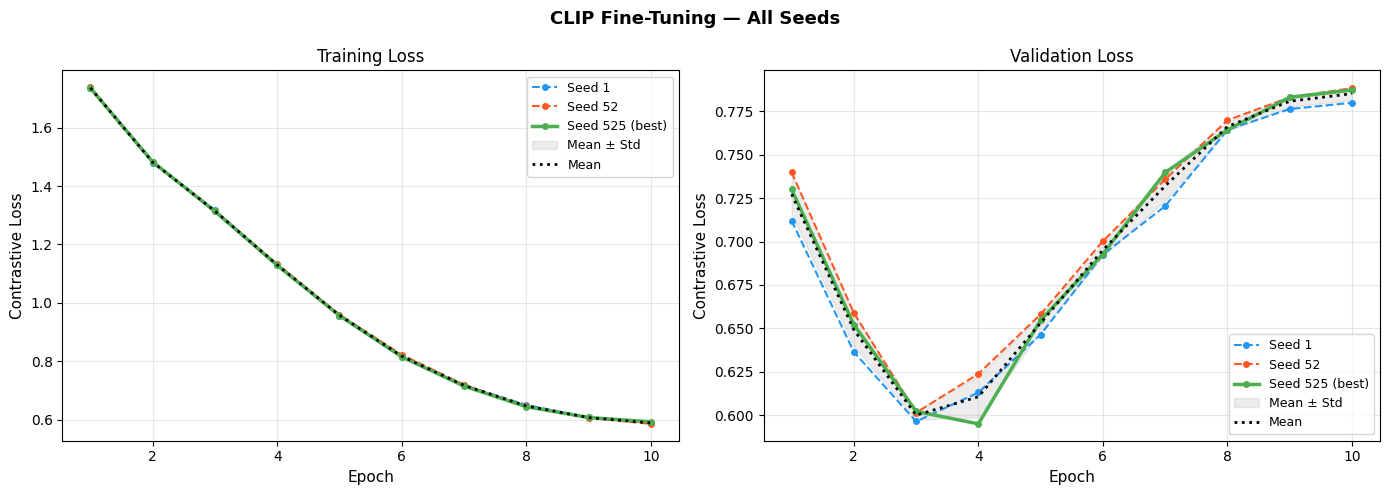

✅  Loss curves saved → /kaggle/working/loss_curves_all_seeds.png


In [22]:
# ─── 14.2  Combined loss curves for all seeds ────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2196F3', '#FF5722', '#4CAF50']   # blue, orange, green

for ax, loss_key, title in [
    (axes[0], 'train_loss', 'Training Loss'),
    (axes[1], 'val_loss',   'Validation Loss'),
]:
    for seed, color in zip(SEEDS, colors):
        hist   = all_seed_histories[seed][loss_key]
        epochs = list(range(1, len(hist) + 1))
        lw     = 2.5 if seed == global_best_seed else 1.5
        ls     = '-'  if seed == global_best_seed else '--'
        label  = f'Seed {seed}' + (' (best)' if seed == global_best_seed else '')
        ax.plot(epochs, hist, color=color, linewidth=lw,
                linestyle=ls, marker='o', markersize=4, label=label)

    # Shaded mean ± std band
    all_vals = np.array([all_seed_histories[s][loss_key] for s in SEEDS])
    mean_v   = all_vals.mean(axis=0)
    std_v    = all_vals.std(axis=0)
    ep_x     = list(range(1, len(mean_v)+1))
    ax.fill_between(ep_x, mean_v - std_v, mean_v + std_v,
                    alpha=0.15, color='grey', label='Mean ± Std')
    ax.plot(ep_x, mean_v, color='black', linewidth=2,
            linestyle=':', label='Mean')

    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Contrastive Loss', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('CLIP Fine-Tuning — All Seeds', fontsize=13, fontweight='bold')
plt.tight_layout()
curve_path = Path(CFG.output_dir) / 'loss_curves_all_seeds.png'
plt.savefig(str(curve_path), dpi=150)
plt.show()
print(f'✅  Loss curves saved → {curve_path}')

---
## Part 15 — Cosine Similarity Sanity Check (Best Seed Model)

Loads `best_clip.pt` (best seed) and verifies that matching
`(image, caption)` pairs score higher than mismatched ones.

In [23]:
# ─── 15.1  Load best model ───────────────────────────────────────────────────

best_model = CLIPModel.from_pretrained(CFG.clip_model_name).to(DEVICE)
load_checkpoint(str(ckpt_dir / 'best_clip.pt'), best_model)
best_model.eval()
print(f'✅  Loaded best_clip.pt  (seed={global_best_seed})')

2026-05-14 07:37:35,266 INFO HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-05-14 07:37:35,273 INFO HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/openai/clip-vit-base-patch32/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268/config.json "HTTP/1.1 200 OK"
2026-05-14 07:37:35,468 INFO HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-05-14 07:37:35,475 INFO HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/openai/clip-vit-base-patch32/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268/config.json "HTTP/1.1 200 OK"
2026-05-14 07:37:35,673 INFO HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-05-14 07:37:35,870 INFO HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safetensors.ind

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

2026-05-14 07:37:36,876 INFO HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/discussions?p=0 "HTTP/1.1 200 OK"
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-05-14 07:37:37,323 INFO HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/commits/refs%2Fpr%2F66 "HTTP/1.1 200 OK"
2026-05-14 07:37:37,526 INFO HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/refs%2Fpr%2F66/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-05-14 07:37:37,727 INFO HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/refs%2Fpr%2F66/mod

✅  Loaded best_clip.pt  (seed=525)


In [24]:
# ─── 15.2  Compute similarity matrix on 8 random val samples ─────────────────

@torch.no_grad()
def compute_image_text_similarity(
    model: CLIPModel,
    processor: CLIPProcessor,
    image_paths: List[str],
    captions: List[str]
) -> np.ndarray:
    images = [Image.open(p).convert('RGB') for p in image_paths]
    inputs = processor(
        text=captions, images=images,
        return_tensors='pt', padding=True,
        truncation=True, max_length=CFG.max_text_length
    )
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    outputs  = model(**inputs)
    img_emb  = F.normalize(outputs.image_embeds, dim=-1).cpu().numpy()
    txt_emb  = F.normalize(outputs.text_embeds,  dim=-1).cpu().numpy()
    return img_emb @ txt_emb.T


# Use val split from the best seed — re-build it
random.seed(global_best_seed)
np.random.seed(global_best_seed)
torch.manual_seed(global_best_seed)

full_ds_check = ClothingDataset(updated_df, clip_processor, CFG.max_text_length)
n_v  = max(1, int(len(full_ds_check) * CFG.val_split))
n_tr = len(full_ds_check) - n_v
_, val_ds_check = random_split(
    full_ds_check, [n_tr, n_v],
    generator=torch.Generator().manual_seed(global_best_seed)
)

N_SAMPLES   = 8
val_indices = random.sample(range(len(val_ds_check)), min(N_SAMPLES, len(val_ds_check)))
val_rows    = updated_df.iloc[
    [val_ds_check.indices[i] for i in val_indices]
].reset_index(drop=True)

sample_paths    = val_rows['crop_path'].tolist()
sample_captions = val_rows['caption'].tolist()

valid_mask      = [Path(p).exists() for p in sample_paths]
sample_paths    = [p for p, m in zip(sample_paths, valid_mask) if m]
sample_captions = [c for c, m in zip(sample_captions, valid_mask) if m]

if sample_paths:
    sim_matrix = compute_image_text_similarity(
        best_model, clip_processor, sample_paths, sample_captions
    )
    diag    = np.diag(sim_matrix)
    offdiag = sim_matrix[~np.eye(len(sim_matrix), dtype=bool)].mean()
    print(f'Diagonal (matching) mean   : {diag.mean():.4f}')
    print(f'Off-diagonal mean          : {offdiag:.4f}')
    print(f'Gap                        : {diag.mean() - offdiag:.4f}')
    if diag.mean() > offdiag:
        print('✅  Matching pairs score higher — model is working correctly!')
    else:
        print('⚠️  Gap is negative — consider more epochs or a lower LR.')
else:
    print('⚠️  No sample images found on disk — skipping similarity check.')

  [Dataset] 52,258 samples | 7,980 unique item_ids
Diagonal (matching) mean   : 0.2711
Off-diagonal mean          : 0.1572
Gap                        : 0.1138
✅  Matching pairs score higher — model is working correctly!


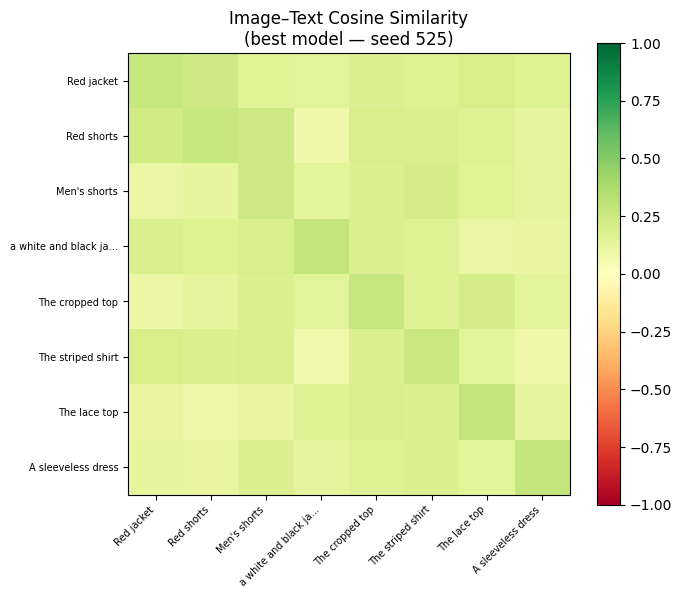

✅  Heatmap saved → /kaggle/working/similarity_heatmap.png


In [25]:
# ─── 15.3  Visualise similarity heatmap ──────────────────────────────────────

if sample_paths:
    N = len(sample_paths)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(sim_matrix, vmin=-1, vmax=1, cmap='RdYlGn')
    ax.set_xticks(range(N))
    ax.set_yticks(range(N))
    short = [c[:20]+'…' if len(c)>20 else c for c in sample_captions]
    ax.set_xticklabels(short, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(short, fontsize=7)
    ax.set_title(f'Image–Text Cosine Similarity\n(best model — seed {global_best_seed})')
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    heatmap_path = Path(CFG.output_dir) / 'similarity_heatmap.png'
    plt.savefig(str(heatmap_path), dpi=150)
    plt.show()
    print(f'✅  Heatmap saved → {heatmap_path}')

### Sample Crops + Captions

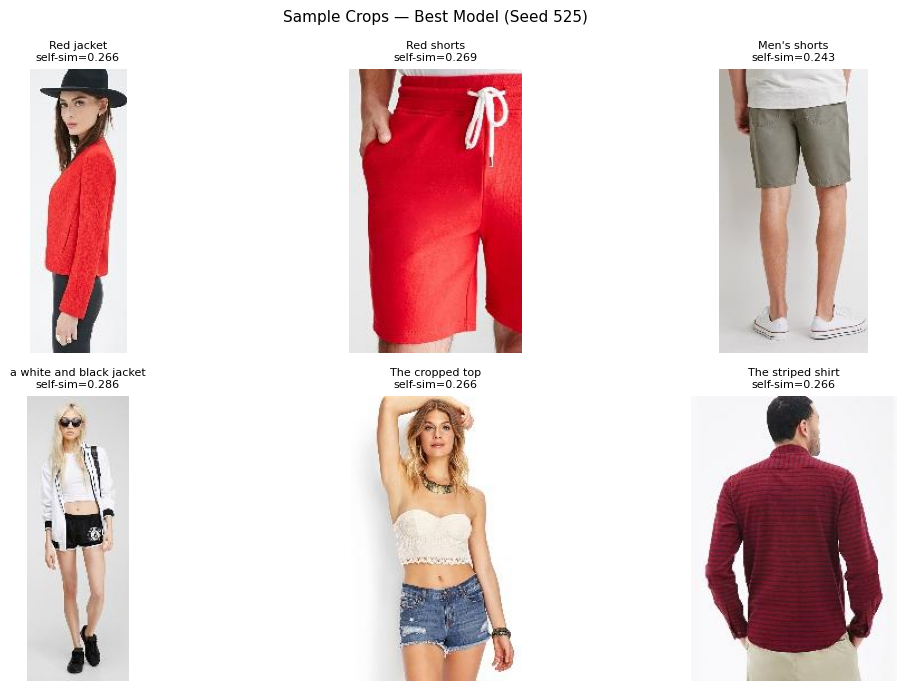

✅  Sample crops figure saved → /kaggle/working/sample_crops.png


In [26]:
# ─── 15.4  Sample crop + caption visualisation ───────────────────────────────

n_show = min(6, len(sample_paths))
if n_show:
    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    axes = axes.flatten()
    for i in range(n_show):
        try:
            img = Image.open(sample_paths[i]).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224,224), (128,128,128))
        axes[i].imshow(img)
        cap   = sample_captions[i]
        score = sim_matrix[i, i]
        axes[i].set_title(
            f'{cap[:30]}…\nself-sim={score:.3f}'
            if len(cap)>30 else f'{cap}\nself-sim={score:.3f}',
            fontsize=8
        )
        axes[i].axis('off')
    for j in range(n_show, len(axes)):
        axes[j].axis('off')
    plt.suptitle(f'Sample Crops — Best Model (Seed {global_best_seed})', fontsize=11)
    plt.tight_layout()
    crops_fig_path = Path(CFG.output_dir) / 'sample_crops.png'
    plt.savefig(str(crops_fig_path), dpi=150)
    plt.show()
    print(f'✅  Sample crops figure saved → {crops_fig_path}')

---
## Part 16 — Per-Seed Checkpoint Listing

All checkpoints produced by this notebook.

In [27]:
# ─── 16.1  List all checkpoints ──────────────────────────────────────────────

print(f'{"File":<40}  {"Size":>8}  {"Notes"}')
print('-' * 70)

def fmt_ckpt(p: Path) -> str:
    if not p.exists():
        return '❌  missing'
    return f'{p.stat().st_size/1e6:.2f} MB'

for s in SEEDS:
    for tag in ['best', 'final']:
        p = ckpt_dir / f'{tag}_clip_seed{s}.pt'
        note = '← globally best' if (tag=='best' and s==global_best_seed) else ''
        print(f'  {p.name:<38}  {fmt_ckpt(p):>8}  {note}')

# Canonical best
p = ckpt_dir / 'best_clip.pt'
print(f'  {"best_clip.pt (canonical)":<38}  {fmt_ckpt(p):>8}  ← copy of best seed')

print()
print(f'{"Artefact":<40}  {"Status"}')
print('-' * 60)
other = {
    'Clothing crops (processed/crops/)': Path(CFG.crops_dir),
    'updated_metadata.csv'             : Path(CFG.updated_metadata),
    'loss_curves_all_seeds.png'        : Path(CFG.output_dir)/'loss_curves_all_seeds.png',
    'similarity_heatmap.png'           : Path(CFG.output_dir)/'similarity_heatmap.png',
    'sample_crops.png'                 : Path(CFG.output_dir)/'sample_crops.png',
}
for name, path in other.items():
    if path.is_dir():
        n = sum(1 for f in path.rglob('*') if f.is_file())
        status = f'✅  {n:,} files'
    elif path.exists():
        status = f'✅  {path.stat().st_size/1e6:.2f} MB'
    else:
        status = '❌  missing'
    print(f'  {name:<40}  {status}')

print()
print('Pass best_clip.pt to Member 3 (retrieval / indexing notebook).')

File                                          Size  Notes
----------------------------------------------------------------------
  best_clip_seed1.pt                      837.39 MB  
  final_clip_seed1.pt                     837.40 MB  
  best_clip_seed52.pt                     837.40 MB  
  final_clip_seed52.pt                    837.40 MB  
  best_clip_seed525.pt                    837.40 MB  ← globally best
  final_clip_seed525.pt                   837.40 MB  
  best_clip.pt (canonical)                837.40 MB  ← copy of best seed

Artefact                                  Status
------------------------------------------------------------
  Clothing crops (processed/crops/)         ✅  52,675 files
  updated_metadata.csv                      ✅  15.04 MB
  loss_curves_all_seeds.png                 ✅  0.17 MB
  similarity_heatmap.png                    ✅  0.08 MB
  sample_crops.png                          ✅  0.71 MB

Pass best_clip.pt to Member 3 (retrieval / indexing notebook).


In [28]:
# ─── Final memory cleanup ─────────────────────────────────────────────────────
del best_model
gc.collect()
if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()
    print(f'GPU memory freed. '
          f'Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB')

GPU memory freed. Allocated: 0.92 GB
